In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pyspark
from pyspark.sql.functions import col
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, regexp_replace, to_date, count, sum as spark_sum, isnan
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/20 19:32:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/20 19:32:20 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# 2. Attributes dataset

In [3]:
attributes_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("sep", ",")
    .csv("./datamart/bronze/features_attributes/bronze_attributes_*.csv")
)
attributes_df.printSchema()
print("Row count:", attributes_df.count())

root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



[Stage 2:>                                                        (0 + 12) / 12]

Row count: 11974


In [4]:
attributes_df.show(truncate=False)

+-----------+----------------+----+-----------+------------+-------------+
|Customer_ID|Name            |Age |SSN        |Occupation  |snapshot_date|
+-----------+----------------+----+-----------+------------+-------------+
|CUS_0x10ac |Zhouy           |29  |780-50-4730|Developer   |2024-08-01   |
|CUS_0x10c5 |Moony           |24  |041-74-6785|_______     |2024-08-01   |
|CUS_0x1145 |Blenkinsopr     |24  |426-31-9194|Teacher     |2024-08-01   |
|CUS_0x11ac |Liana B.v       |26_ |835-92-7751|Journalist  |2024-08-01   |
|CUS_0x122c |Papadimasf      |48  |883-73-9594|Entrepreneur|2024-08-01   |
|CUS_0x1274 |Whited          |5656|298-61-0480|Scientist   |2024-08-01   |
|CUS_0x1288 |Taylorq         |34_ |609-85-2725|Doctor      |2024-08-01   |
|CUS_0x12cc |Lauren Tarat    |30  |761-36-5969|Developer   |2024-08-01   |
|CUS_0x1338 |Olivia Orang    |40  |250-62-9181|_______     |2024-08-01   |
|CUS_0x1370 |Rothackerb      |32  |710-06-0138|Writer      |2024-08-01   |
|CUS_0x1378 |Alan Wheatle

### Check null column


In [5]:
attributes_df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in attributes_df.columns
]).show()

+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|  0|  0|         0|            0|
+-----------+----+---+---+----------+-------------+



In [6]:
attributes_df.groupBy("Occupation").count().orderBy(F.desc("count")).show(50, truncate=False)

+-------------+-----+
|Occupation   |count|
+-------------+-----+
|_______      |846  |
|Lawyer       |785  |
|Architect    |766  |
|Accountant   |763  |
|Engineer     |754  |
|Teacher      |751  |
|Media_Manager|750  |
|Mechanic     |750  |
|Scientist    |746  |
|Developer    |746  |
|Entrepreneur |744  |
|Journalist   |741  |
|Doctor       |729  |
|Musician     |709  |
|Manager      |700  |
|Writer       |694  |
+-------------+-----+



In [7]:
print("Count SSN dirty rows: ", attributes_df.filter(col("SSN") == "#F%$D@*&8").count())
print("Count Occupation dirty rows: ", attributes_df.filter(col("Occupation") == "_______").count())


Count SSN dirty rows:  676
Count Occupation dirty rows:  846


### Clean up messy text in SSN, Occupation, Age, then cast Age to int

In [ ]:
attributes_cleaned_df = (
    attributes_df
    .filter(col("SSN") != "#F%$D@*&8")
    .drop("SSN")  # PII
    .filter(col("Occupation") != "_______")
    .withColumn("Age", regexp_replace(col("Age").cast("string"), "[^0-9-]", ""))
    .withColumn("Age", col("Age").cast(IntegerType()))
)
attributes_cleaned_df.printSchema()
print("Rows after clean:", attributes_cleaned_df.count())
attributes_cleaned_df.show(5)

In [9]:
# unique customer in the dataset. Make sure no multiplee cust entries
print("Unique customers:", attributes_cleaned_df.select("Customer_ID").distinct().count())

[Stage 22:>                                                       (0 + 12) / 12]

Unique customers: 10501


### Double check if the dirty rows are gone

In [ ]:
# SSN column dropped in cleaning step (PII) — no check needed

# Check Occupation underscores are gone
print("Bad Occupation rows:", attributes_cleaned_df.filter(col("Occupation") == "_______").count())

# Check Age
print("Rows with _ in Age:", attributes_cleaned_df.filter(col("Age").rlike("_")).count())
attributes_cleaned_df.select("Age").describe().show()


### Visualisation

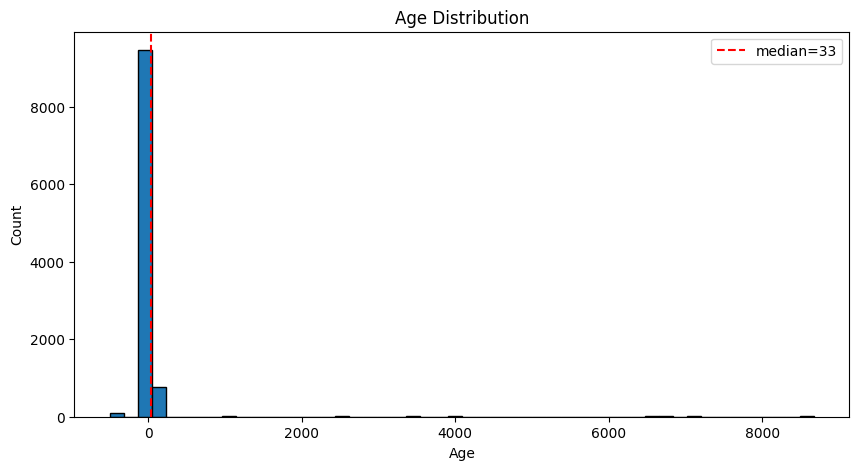

rows with Age > 70: 181
rows with Age < 18 : 639
rows with Age >= 18 and <= 70: 9681


In [11]:
# visualize age distribution
ages = attributes_cleaned_df.select("Age").toPandas()

plt.figure(figsize=(10, 5))
plt.hist(ages["Age"].dropna(), bins=50, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.axvline(ages["Age"].median(), color="red", linestyle="--", label=f"median={ages['Age'].median():.0f}")
plt.legend()
plt.show()

# check unrealistic age rows
print("rows with Age > 70:", (ages["Age"] > 70).sum())
print("rows with Age < 18 :", (ages["Age"] < 18).sum())
print(
    "rows with Age >= 18 and <= 70:",
    ((ages["Age"] >= 18) & (ages["Age"] <= 70)).sum()
)

### Drop age that is below 18 and above 70

In [12]:
before = attributes_cleaned_df.count()
attributes_cleaned_df = attributes_cleaned_df.filter((col("Age") >= 18) & (col("Age") <= 70))
after = attributes_cleaned_df.count()
print(f"Rows after Age filter: {after} (dropped {before - after})")

Rows after Age filter: 9681 (dropped 820)
